# Section 1: Import Libraries and Setup

In [1]:
import os
import cv2 as cv2

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import tensorflow as tf


from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, regularizers
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight

In [8]:
if tf.config.list_physical_devices('GPU'):
    print("GPU is available.")
else:
    print("GPU is NOT available.")

GPU is available.


# Downloading Data from Kaggle

In [ ]:
#import kagglehub

# Download latest version
#path = kagglehub.dataset_download("noodulz/pokemon-dataset-1000")

#print("Path to dataset files:", path)

In [2]:
train_datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
)

In [9]:
# Define the dataset path on Kaggle
path = 'D:/files/LUND/DeepLearning/project/pokemon-dataset-1000/'
dataset_path = path + 'dataset'
train_path = path + 'train'
test_path = path + 'test'
val_path = path + 'val'

In [7]:
def generate_train_labels(Train_path, save_path="train_labels.npy"):
    # 获取类别名和索引映射
    class_names = sorted([name for name in os.listdir(Train_path) if os.path.isdir(os.path.join(Train_path, name))])
    class_to_idx = {name: idx for idx, name in enumerate(class_names)}
    
    # 生成标签
    train_labels = []
    for class_name in class_names:
        class_dir = os.path.join(Train_path, class_name)
        for img_file in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_file)
            if os.path.isfile(img_path):
                train_labels.append(class_to_idx[class_name])
    
    # 保存为.npy文件
    train_labels = np.array(train_labels, dtype=np.int32)
    np.save(save_path, train_labels)
    print(f"标签已保存至 {save_path}，共 {len(train_labels)} 个样本")

# 调用函数
generate_train_labels(Train_path=train_path,save_path=path+'train_labels.npy')

标签已保存至 D:/files/LUND/DeepLearning/project/pokemon-dataset-1000/train_labels.npy，共 19434 个样本


In [11]:
train_dataset = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),  # 与预处理尺寸一致
    batch_size=128,
    class_mode='categorical',  # 多分类任务
    seed=42
)

Found 19434 images belonging to 1000 classes.


In [13]:
val_dataset = image_dataset_from_directory(
    val_path,
    label_mode="categorical",
    image_size=(224, 224),
    seed=42
)

Found 2815 files belonging to 1000 classes.


In [14]:
test_dataset = image_dataset_from_directory(
    test_path,
    label_mode="categorical",
    image_size=(224, 224),
    seed=42
)

Found 4290 files belonging to 1000 classes.


In [17]:
train_labels = np.load("train_labels.npy")
class_weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
class_weight_dict = dict(enumerate(class_weights))

In [19]:
def print_model_parameters(model):
    trainable_params = np.sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
    non_trainable_params = np.sum([tf.keras.backend.count_params(w) for w in model.non_trainable_weights])
    total_params = trainable_params + non_trainable_params
    
    print(f"Total Parameters: {total_params:,}")
    print(f"Trainable Parameters: {trainable_params:,}")
    print(f"Non-Trainable Parameters: {non_trainable_params:,}")
    return total_params, trainable_params, non_trainable_params

# ResNet1 Learning Rate 0.001 Adam

In [21]:
# 构建ResNet模型
base_model = tf.keras.applications.ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False  # 冻结预训练层

model_resnet = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(1024, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1000, activation='softmax')
])
lr_schedule = ExponentialDecay(initial_learning_rate=0.001,
                               decay_steps=1000,
                               decay_rate=0.96,
                               staircase=True)
optimizer = Adam(learning_rate=lr_schedule)


In [22]:
model_resnet.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 训练（epochs=20）
total_params, trainable_params, _ = print_model_parameters(model_resnet)

Total Parameters: 26,710,888
Trainable Parameters: 3,123,176
Non-Trainable Parameters: 23,587,712


In [14]:
history_resnet = model_resnet.fit(
    
    train_dataset,
    epochs=30,
    validation_data=val_dataset,
    class_weight=class_weight_dict
)

Epoch 1/30
152/152 [==============================] - 236s 2s/step - loss: 7.1231 - accuracy: 0.0053 - val_loss: 5.8307 - val_accuracy: 0.0721
Epoch 2/30
152/152 [==============================] - 123s 805ms/step - loss: 5.7587 - accuracy: 0.0635 - val_loss: 4.1152 - val_accuracy: 0.3012
Epoch 3/30
152/152 [==============================] - 123s 810ms/step - loss: 4.4174 - accuracy: 0.1633 - val_loss: 3.1000 - val_accuracy: 0.4174
Epoch 4/30
152/152 [==============================] - 123s 808ms/step - loss: 3.5511 - accuracy: 0.2548 - val_loss: 2.3569 - val_accuracy: 0.5361
Epoch 5/30
152/152 [==============================] - 123s 809ms/step - loss: 2.9905 - accuracy: 0.3183 - val_loss: 1.9651 - val_accuracy: 0.5933
Epoch 6/30
152/152 [==============================] - 123s 806ms/step - loss: 2.5880 - accuracy: 0.3857 - val_loss: 1.6835 - val_accuracy: 0.6409
Epoch 7/30
152/152 [==============================] - 122s 803ms/step - loss: 2.2806 - accuracy: 0.4264 - val_loss: 1.5046 - va

In [15]:
test_loss, test_acc = model_resnet.evaluate(test_dataset)
print(f"Test Accuracy: {test_acc:.4f}")

135/135 [==============================] - 30s 211ms/step - loss: 0.6937 - accuracy: 0.8373
Test Accuracy: 0.8373


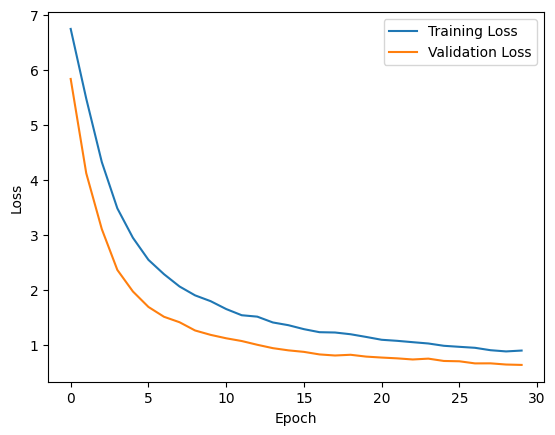

In [16]:
plt.plot(history_resnet.history['loss'], label='Training Loss')
plt.plot(history_resnet.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

 # ResNet2 Learning Rate 0.0001 Adam

In [25]:
lr_schedule = ExponentialDecay(initial_learning_rate=0.0001,
                               decay_steps=1000,
                               decay_rate=0.96,
                               staircase=True)
optimizer = Adam(learning_rate=lr_schedule)
model_resnet.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 训练（epochs=20）

Total Parameters: 26,710,888
Trainable Parameters: 3,123,176
Non-Trainable Parameters: 23,587,712


In [19]:
history_resnet2 = model_resnet.fit(
    
    train_dataset,
    epochs=30,
    validation_data=val_dataset,
    class_weight=class_weight_dict
)

Epoch 1/30
152/152 [==============================] - 125s 811ms/step - loss: 0.7351 - accuracy: 0.7548 - val_loss: 0.5854 - val_accuracy: 0.8572
Epoch 2/30
152/152 [==============================] - 123s 806ms/step - loss: 0.7187 - accuracy: 0.7612 - val_loss: 0.5800 - val_accuracy: 0.8554
Epoch 3/30
152/152 [==============================] - 123s 806ms/step - loss: 0.6915 - accuracy: 0.7667 - val_loss: 0.5810 - val_accuracy: 0.8579
Epoch 4/30
152/152 [==============================] - 123s 808ms/step - loss: 0.6774 - accuracy: 0.7743 - val_loss: 0.5795 - val_accuracy: 0.8561
Epoch 5/30
152/152 [==============================] - 123s 809ms/step - loss: 0.6899 - accuracy: 0.7743 - val_loss: 0.5704 - val_accuracy: 0.8572
Epoch 6/30
152/152 [==============================] - 123s 807ms/step - loss: 0.6642 - accuracy: 0.7740 - val_loss: 0.5674 - val_accuracy: 0.8572
Epoch 7/30
152/152 [==============================] - 123s 809ms/step - loss: 0.6484 - accuracy: 0.7740 - val_loss: 0.5688 -

In [20]:
test_loss, test_acc = model_resnet.evaluate(test_dataset)
print(f"Test Accuracy: {test_acc:.4f}")

135/135 [==============================] - 12s 87ms/step - loss: 0.6092 - accuracy: 0.8636
Test Accuracy: 0.8636


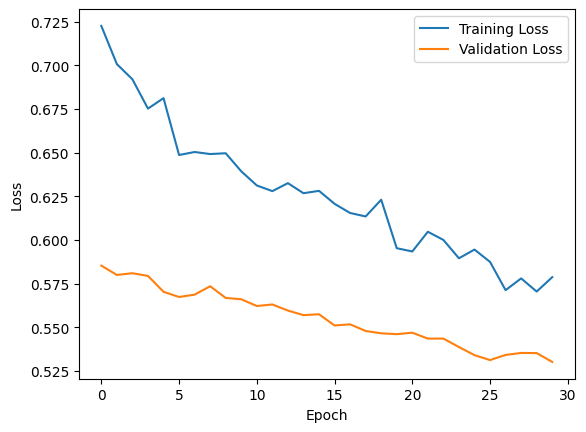

In [21]:
plt.plot(history_resnet2.history['loss'], label='Training Loss')
plt.plot(history_resnet2.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# ResNet3 Learning Rate 0.0001 Nadam

In [23]:
optimizer = tf.keras.optimizers.Nadam(
    learning_rate=0.0001,
    beta_1=0.9,  # 一阶矩估计衰减率
    beta_2=0.999  # 二阶矩估计衰减率
)
model_resnet.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 训练（epochs=20）


In [24]:
history_resnet3 = model_resnet.fit(
    
    train_dataset,
    epochs=30,
    validation_data=val_dataset,
    class_weight=class_weight_dict
)

Epoch 1/30
152/152 [==============================] - 128s 828ms/step - loss: 0.7102 - accuracy: 0.7641 - val_loss: 0.6063 - val_accuracy: 0.8512
Epoch 2/30
152/152 [==============================] - 126s 827ms/step - loss: 0.7855 - accuracy: 0.7507 - val_loss: 0.6130 - val_accuracy: 0.8512
Epoch 3/30
152/152 [==============================] - 126s 828ms/step - loss: 0.7709 - accuracy: 0.7413 - val_loss: 0.5914 - val_accuracy: 0.8551
Epoch 4/30
152/152 [==============================] - 126s 826ms/step - loss: 0.7670 - accuracy: 0.7463 - val_loss: 0.5948 - val_accuracy: 0.8579
Epoch 5/30
152/152 [==============================] - 126s 826ms/step - loss: 0.7555 - accuracy: 0.7526 - val_loss: 0.5999 - val_accuracy: 0.8529
Epoch 6/30
152/152 [==============================] - 126s 825ms/step - loss: 0.7491 - accuracy: 0.7534 - val_loss: 0.5947 - val_accuracy: 0.8519
Epoch 7/30
152/152 [==============================] - 126s 827ms/step - loss: 0.7104 - accuracy: 0.7592 - val_loss: 0.5684 -

In [25]:
test_loss, test_acc = model_resnet.evaluate(test_dataset)
print(f"Test Accuracy: {test_acc:.4f}")

135/135 [==============================] - 12s 86ms/step - loss: 0.6164 - accuracy: 0.8737
Test Accuracy: 0.8737


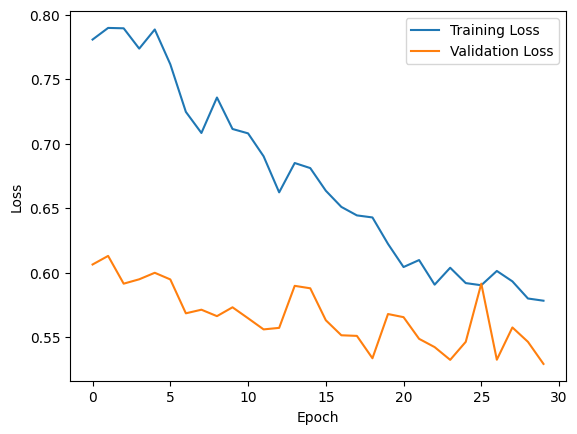

In [26]:
plt.plot(history_resnet3.history['loss'], label='Training Loss')
plt.plot(history_resnet3.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# ResNet4 Learning Rate 0.0001 SGD

In [28]:
lr_schedule = ExponentialDecay(initial_learning_rate=0.0001,
                               decay_steps=1000,
                               decay_rate=0.96,
                               staircase=True)
optimizer = tf.keras.optimizers.SGD(learning_rate=lr_schedule, momentum=0.9)

In [29]:
history_resnet4 = model_resnet.fit(
    
    train_dataset,
    epochs=30,
    validation_data=val_dataset,
    class_weight=class_weight_dict
)

Epoch 1/30
152/152 [==============================] - 123s 806ms/step - loss: 0.5874 - accuracy: 0.7989 - val_loss: 0.5460 - val_accuracy: 0.8725
Epoch 2/30
152/152 [==============================] - 123s 807ms/step - loss: 0.5898 - accuracy: 0.7998 - val_loss: 0.5427 - val_accuracy: 0.8689
Epoch 3/30
152/152 [==============================] - 123s 807ms/step - loss: 0.5752 - accuracy: 0.7997 - val_loss: 0.5336 - val_accuracy: 0.8703
Epoch 4/30
152/152 [==============================] - 123s 808ms/step - loss: 0.5573 - accuracy: 0.8048 - val_loss: 0.5363 - val_accuracy: 0.8806
Epoch 5/30
152/152 [==============================] - 123s 808ms/step - loss: 0.5374 - accuracy: 0.8099 - val_loss: 0.5447 - val_accuracy: 0.8742
Epoch 6/30
152/152 [==============================] - 123s 807ms/step - loss: 0.5379 - accuracy: 0.8096 - val_loss: 0.5388 - val_accuracy: 0.8753
Epoch 7/30
152/152 [==============================] - 123s 807ms/step - loss: 0.5732 - accuracy: 0.8063 - val_loss: 0.5426 -

In [30]:
test_loss, test_acc = model_resnet.evaluate(test_dataset)
print(f"Test Accuracy: {test_acc:.4f}")

135/135 [==============================] - 12s 86ms/step - loss: 0.6724 - accuracy: 0.8718
Test Accuracy: 0.8718


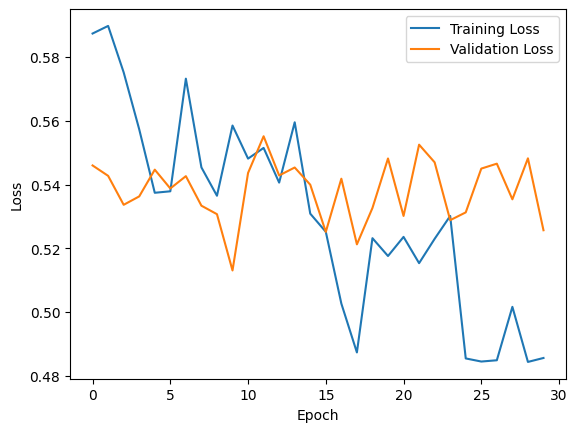

In [31]:
plt.plot(history_resnet4.history['loss'], label='Training Loss')
plt.plot(history_resnet4.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# MoblieNet1 learning rate=0.001 Adam

In [27]:
base_model = tf.keras.applications.MobileNetV2(input_shape=(224, 224, 3),
                         include_top=False,
                         weights='imagenet')
base_model.trainable = False  

model_mobilenet = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.3),
    layers.Dense(1000, activation='softmax')
])

lr_schedule = ExponentialDecay(initial_learning_rate=0.001,
                               decay_steps=1000,
                               decay_rate=0.96,
                               staircase=True)
optimizer = Adam(learning_rate=lr_schedule)
model_mobilenet.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

total_params, trainable_params, _ = print_model_parameters(model_mobilenet)

Total Parameters: 3,304,232
Trainable Parameters: 1,045,224
Non-Trainable Parameters: 2,259,008


In [40]:
history_mobilenet1 = model_mobilenet.fit(
    train_dataset, 
    epochs=30, 
    validation_data=val_dataset, 
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)

Epoch 1/30
152/152 [==============================] - 124s 804ms/step - loss: 7.9917 - accuracy: 0.0041 - val_loss: 6.7633 - val_accuracy: 0.0394
Epoch 2/30
152/152 [==============================] - 121s 793ms/step - loss: 6.7572 - accuracy: 0.0325 - val_loss: 5.4009 - val_accuracy: 0.1346
Epoch 3/30
152/152 [==============================] - 121s 796ms/step - loss: 5.6221 - accuracy: 0.0811 - val_loss: 4.6947 - val_accuracy: 0.2004
Epoch 4/30
152/152 [==============================] - 120s 789ms/step - loss: 4.9127 - accuracy: 0.1330 - val_loss: 4.1702 - val_accuracy: 0.2657
Epoch 5/30
152/152 [==============================] - 120s 790ms/step - loss: 4.4831 - accuracy: 0.1721 - val_loss: 3.7687 - val_accuracy: 0.3162
Epoch 6/30
152/152 [==============================] - 120s 788ms/step - loss: 4.1959 - accuracy: 0.2027 - val_loss: 3.5926 - val_accuracy: 0.3496
Epoch 7/30
152/152 [==============================] - 120s 790ms/step - loss: 3.9855 - accuracy: 0.2322 - val_loss: 3.4160 -

In [41]:
test_loss, test_acc = model_mobilenet.evaluate(test_dataset)
print(f"Test Accuracy: {test_acc:.4f}")

135/135 [==============================] - 8s 58ms/step - loss: 2.4420 - accuracy: 0.5739
Test Accuracy: 0.5739


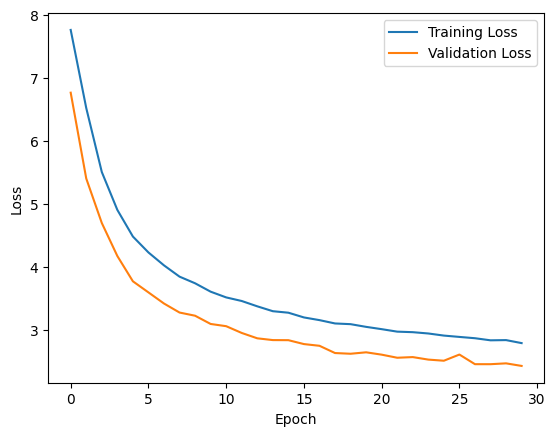

In [42]:
plt.plot(history_mobilenet1.history['loss'], label='Training Loss')
plt.plot(history_mobilenet1.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# MobileNet2 learning rate=0.0001 Adam

In [44]:
lr_schedule = ExponentialDecay(initial_learning_rate=0.0001,
                               decay_steps=1000,
                               decay_rate=0.96,
                               staircase=True)
optimizer = Adam(learning_rate=lr_schedule)
model_mobilenet.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

# 训练（epochs=15）

In [45]:
history_mobilenet2 = model_mobilenet.fit(
    train_dataset, 
    epochs=30, 
    validation_data=val_dataset,
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)

Epoch 1/30
152/152 [==============================] - 122s 796ms/step - loss: 2.6814 - accuracy: 0.4342 - val_loss: 2.2373 - val_accuracy: 0.6188
Epoch 2/30
152/152 [==============================] - 121s 794ms/step - loss: 2.5433 - accuracy: 0.4479 - val_loss: 2.1921 - val_accuracy: 0.6256
Epoch 3/30
152/152 [==============================] - 120s 792ms/step - loss: 2.4712 - accuracy: 0.4619 - val_loss: 2.1720 - val_accuracy: 0.6309
Epoch 4/30
152/152 [==============================] - 120s 792ms/step - loss: 2.4336 - accuracy: 0.4639 - val_loss: 2.1384 - val_accuracy: 0.6359
Epoch 5/30
152/152 [==============================] - 121s 794ms/step - loss: 2.4392 - accuracy: 0.4686 - val_loss: 2.1196 - val_accuracy: 0.6373
Epoch 6/30
152/152 [==============================] - 120s 792ms/step - loss: 2.3994 - accuracy: 0.4743 - val_loss: 2.1020 - val_accuracy: 0.6384
Epoch 7/30
152/152 [==============================] - 121s 792ms/step - loss: 2.3899 - accuracy: 0.4792 - val_loss: 2.0999 -

In [46]:
test_loss, test_acc = model_mobilenet.evaluate(test_dataset)
print(f"Test Accuracy: {test_acc:.4f}")

135/135 [==============================] - 8s 59ms/step - loss: 1.9170 - accuracy: 0.6685
Test Accuracy: 0.6685


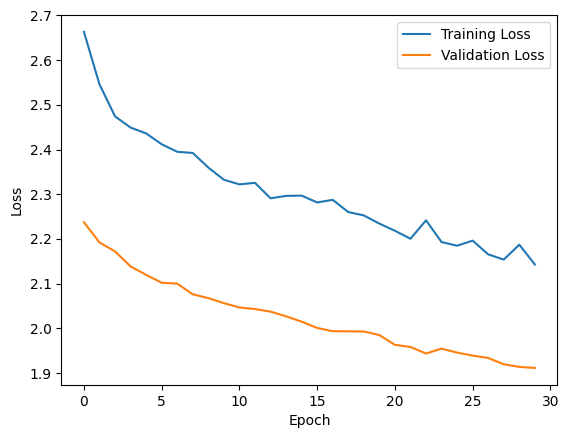

In [47]:
plt.plot(history_mobilenet2.history['loss'], label='Training Loss')
plt.plot(history_mobilenet2.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# MobileNet3 learning rate=0.0001 Nadam

In [74]:
optimizer = tf.keras.optimizers.Nadam(
    learning_rate=0.0001,
    beta_1=0.9,  # 一阶矩估计衰减率
    beta_2=0.999  # 二阶矩估计衰减率
)
model_resnet.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

In [76]:
history_mobilenet3 = model_mobilenet.fit(
    train_dataset, 
    epochs=30, 
    validation_data=val_dataset, 
    class_weight=class_weight_dict,
)

Epoch 1/30
152/152 [==============================] - 120s 790ms/step - loss: 2.0564 - accuracy: 0.5292 - val_loss: 1.8656 - val_accuracy: 0.6728
Epoch 2/30
152/152 [==============================] - 120s 788ms/step - loss: 2.0962 - accuracy: 0.5148 - val_loss: 1.8630 - val_accuracy: 0.6710
Epoch 3/30
152/152 [==============================] - 120s 786ms/step - loss: 2.0801 - accuracy: 0.5229 - val_loss: 1.8627 - val_accuracy: 0.6714
Epoch 4/30
152/152 [==============================] - 120s 788ms/step - loss: 2.0850 - accuracy: 0.5152 - val_loss: 1.8621 - val_accuracy: 0.6735
Epoch 5/30
152/152 [==============================] - 120s 790ms/step - loss: 2.0637 - accuracy: 0.5174 - val_loss: 1.8617 - val_accuracy: 0.6732
Epoch 6/30
152/152 [==============================] - 120s 788ms/step - loss: 2.0819 - accuracy: 0.5217 - val_loss: 1.8625 - val_accuracy: 0.6693
Epoch 7/30
152/152 [==============================] - 120s 787ms/step - loss: 2.0758 - accuracy: 0.5172 - val_loss: 1.8599 -

In [77]:
test_loss, test_acc = model_mobilenet.evaluate(test_dataset)
print(f"Test Accuracy: {test_acc:.4f}")

135/135 [==============================] - 8s 60ms/step - loss: 1.8482 - accuracy: 0.6834
Test Accuracy: 0.6834


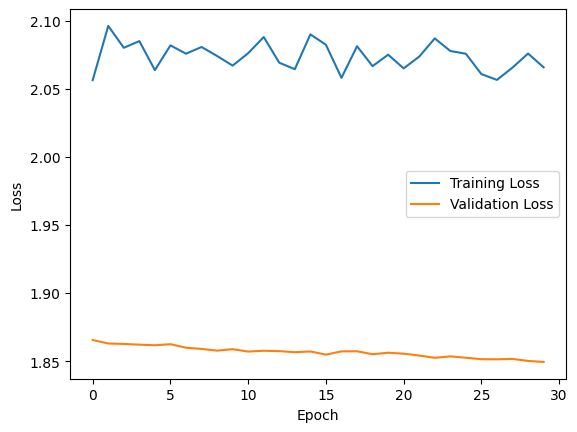

In [78]:
plt.plot(history_mobilenet3.history['loss'], label='Training Loss')
plt.plot(history_mobilenet3.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# MobileNet4 learning rate=0.0001 SGD

In [80]:
lr_schedule = ExponentialDecay(initial_learning_rate=0.0001,
                               decay_steps=1000,
                               decay_rate=0.96,
                               staircase=True)
optimizer = tf.keras.optimizers.SGD(learning_rate=lr_schedule, momentum=0.9)
model_mobilenet.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

In [81]:
history_mobilenet4 = model_mobilenet.fit(
    train_dataset, 
    epochs=30, 
    validation_data=val_dataset, 
    class_weight=class_weight_dict,
)

Epoch 1/30
152/152 [==============================] - 122s 791ms/step - loss: 2.0527 - accuracy: 0.5268 - val_loss: 1.8503 - val_accuracy: 0.6714
Epoch 2/30
152/152 [==============================] - 120s 791ms/step - loss: 2.0824 - accuracy: 0.5122 - val_loss: 1.8495 - val_accuracy: 0.6721
Epoch 3/30
152/152 [==============================] - 121s 795ms/step - loss: 2.0483 - accuracy: 0.5290 - val_loss: 1.8497 - val_accuracy: 0.6725
Epoch 4/30
152/152 [==============================] - 121s 796ms/step - loss: 2.0723 - accuracy: 0.5219 - val_loss: 1.8489 - val_accuracy: 0.6725
Epoch 5/30
152/152 [==============================] - 121s 795ms/step - loss: 2.1189 - accuracy: 0.5139 - val_loss: 1.8504 - val_accuracy: 0.6710
Epoch 6/30
152/152 [==============================] - 120s 792ms/step - loss: 2.0921 - accuracy: 0.5135 - val_loss: 1.8500 - val_accuracy: 0.6718
Epoch 7/30
152/152 [==============================] - 120s 791ms/step - loss: 2.0844 - accuracy: 0.5206 - val_loss: 1.8465 -

In [82]:
test_loss, test_acc = model_mobilenet.evaluate(test_dataset)
print(f"Test Accuracy: {test_acc:.4f}")

135/135 [==============================] - 8s 59ms/step - loss: 1.8375 - accuracy: 0.6858
Test Accuracy: 0.6858


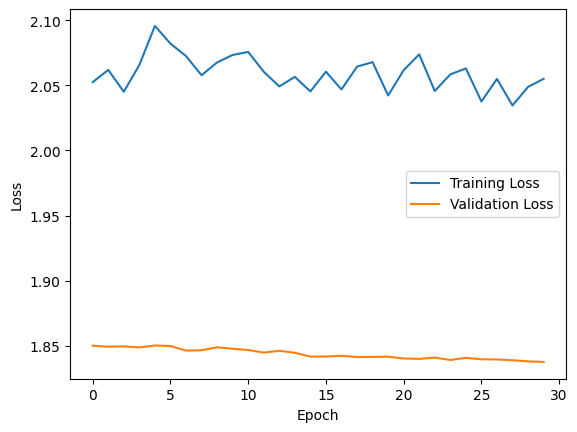

In [83]:
plt.plot(history_mobilenet4.history['loss'], label='Training Loss')
plt.plot(history_mobilenet4.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# CNN1 Learning Rate = 0.001 Adam

In [29]:
def pre_process_and_build_image_dataset(folder_path):
    for root, dirs, files in os.walk(folder_path):
        for poke in dirs:
            poke_dir = os.path.join(root, poke)
            for image in os.listdir(poke_dir):
                original_image_path = os.path.join(poke_dir, image)
                
                # 读取原始图像（BGR三通道）
                img = cv2.imread(original_image_path)
                if img is None:
                    print(f"Warning: Failed to read image {original_image_path}")
                    continue
                
                # 调整大小为32x32并覆盖原始文件
                img_resized = cv2.resize(img, (32, 32))
                cv2.imwrite(original_image_path, img_resized)  # 直接覆盖原图

    print(f"Preprocessing completed for {folder_path}")

In [31]:
pre_process_and_build_image_dataset(train_path)
pre_process_and_build_image_dataset(test_path)
pre_process_and_build_image_dataset(val_path)

Preprocessing completed for D:/files/LUND/DeepLearning/project/pokemon-dataset-1000/train
Preprocessing completed for D:/files/LUND/DeepLearning/project/pokemon-dataset-1000/test
Preprocessing completed for D:/files/LUND/DeepLearning/project/pokemon-dataset-1000/val


In [33]:
train_dataset = train_datagen.flow_from_directory(
    train_path,
    target_size=(32, 32),  # 与预处理尺寸一致
    batch_size=128,
    class_mode='categorical',  # 多分类任务
    seed=42
)

Found 19434 images belonging to 1000 classes.


In [35]:
val_dataset = image_dataset_from_directory(
    val_path,
    label_mode="categorical",
    image_size=(32, 32),
    seed=42
)

Found 2815 files belonging to 1000 classes.


In [37]:
test_dataset = image_dataset_from_directory(
    test_path,
    label_mode="categorical",
    image_size=(32, 32),
    seed=42
)


Found 4290 files belonging to 1000 classes.


In [39]:
model_CNN = models.Sequential([
    layers.Input(shape=(32, 32, 3)),  
    
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu'),
    layers.MaxPool2D(pool_size=(2, 2)),
    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPool2D(pool_size=(2, 2)),
    layers.Conv2D(filters=128, kernel_size=(3, 3), activation='relu'),
    layers.Conv2D(filters=256, kernel_size=(3, 3), activation='relu'),
    layers.Flatten(),  # 确保拼写正确
    layers.Dense(256, activation="relu"),
    layers.Dense(512, activation="relu"),
    layers.Dense(1024, activation="relu"),
    layers.Dense(2048, activation="relu"),
    layers.Dense(1000, activation="softmax")
])

In [41]:
lr_schedule = ExponentialDecay(initial_learning_rate=0.001,
                               decay_steps=1000,
                               decay_rate=0.96,
                               staircase=True)
optimizer = Adam(learning_rate=lr_schedule)

model_CNN.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
total_params, trainable_params, _ = print_model_parameters(model_CNN)

Total Parameters: 5,455,912.0
Trainable Parameters: 5,455,912
Non-Trainable Parameters: 0.0


In [21]:
history_CNN1 = model_CNN.fit(
    train_dataset,
    epochs=30,
    batch_size=128,
    validation_data=val_dataset
)

Epoch 1/30
152/152 [==============================] - 163s 1s/step - loss: 6.8625 - accuracy: 0.0011 - val_loss: 6.3684 - val_accuracy: 0.0046
Epoch 2/30
152/152 [==============================] - 13s 84ms/step - loss: 6.1781 - accuracy: 0.0066 - val_loss: 6.1341 - val_accuracy: 0.0075
Epoch 3/30
152/152 [==============================] - 13s 85ms/step - loss: 5.9670 - accuracy: 0.0083 - val_loss: 6.0156 - val_accuracy: 0.0099
Epoch 4/30
152/152 [==============================] - 13s 84ms/step - loss: 5.6852 - accuracy: 0.0163 - val_loss: 6.2549 - val_accuracy: 0.0171
Epoch 5/30
152/152 [==============================] - 13s 85ms/step - loss: 5.3527 - accuracy: 0.0283 - val_loss: 5.6383 - val_accuracy: 0.0306
Epoch 6/30
152/152 [==============================] - 13s 84ms/step - loss: 4.9516 - accuracy: 0.0502 - val_loss: 6.3571 - val_accuracy: 0.0249
Epoch 7/30
152/152 [==============================] - 13s 84ms/step - loss: 4.5899 - accuracy: 0.0706 - val_loss: 5.8021 - val_accuracy: 

In [22]:
test_loss, test_acc = model_CNN.evaluate(test_dataset)
print(f"Test Accuracy: {test_acc:.4f}")

135/135 [==============================] - 30s 212ms/step - loss: 5.4619 - accuracy: 0.2212
Test Accuracy: 0.2212


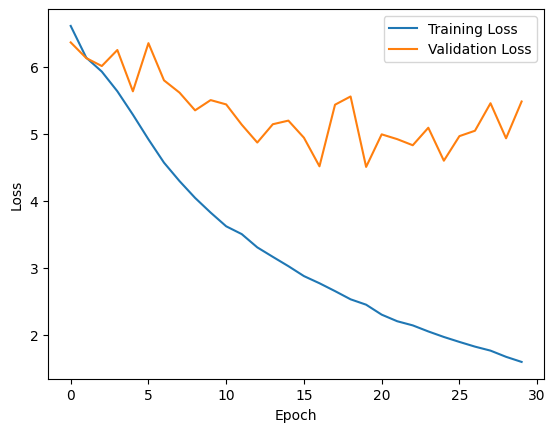

In [23]:
plt.plot(history_CNN1.history['loss'], label='Training Loss')
plt.plot(history_CNN1.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# CNN Learning Rate = 0.0001 Adam

In [25]:
lr_schedule = ExponentialDecay(initial_learning_rate=0.0001,
                               decay_steps=1000,
                               decay_rate=0.96,
                               staircase=True)
optimizer = Adam(learning_rate=lr_schedule)

model_CNN.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [26]:
history_CNN2 = model_CNN.fit(
    train_dataset,
    epochs=30,
    batch_size=128,
    validation_data=val_dataset
)

Epoch 1/30
152/152 [==============================] - 13s 85ms/step - loss: 1.2373 - accuracy: 0.6456 - val_loss: 5.4595 - val_accuracy: 0.2607
Epoch 2/30
152/152 [==============================] - 13s 82ms/step - loss: 1.0388 - accuracy: 0.7033 - val_loss: 5.8750 - val_accuracy: 0.2679
Epoch 3/30
152/152 [==============================] - 13s 83ms/step - loss: 0.9542 - accuracy: 0.7251 - val_loss: 5.6130 - val_accuracy: 0.2799
Epoch 4/30
152/152 [==============================] - 13s 82ms/step - loss: 0.9563 - accuracy: 0.7278 - val_loss: 6.1015 - val_accuracy: 0.2600
Epoch 5/30
152/152 [==============================] - 13s 83ms/step - loss: 0.9053 - accuracy: 0.7430 - val_loss: 5.8844 - val_accuracy: 0.2853
Epoch 6/30
152/152 [==============================] - 13s 83ms/step - loss: 0.8805 - accuracy: 0.7455 - val_loss: 5.6100 - val_accuracy: 0.3076
Epoch 7/30
152/152 [==============================] - 13s 83ms/step - loss: 0.8787 - accuracy: 0.7457 - val_loss: 6.2501 - val_accuracy:

In [27]:
test_loss, test_acc = model_CNN.evaluate(test_dataset)
print(f"Test Accuracy: {test_acc:.4f}")

135/135 [==============================] - 3s 19ms/step - loss: 7.1933 - accuracy: 0.3028
Test Accuracy: 0.3028


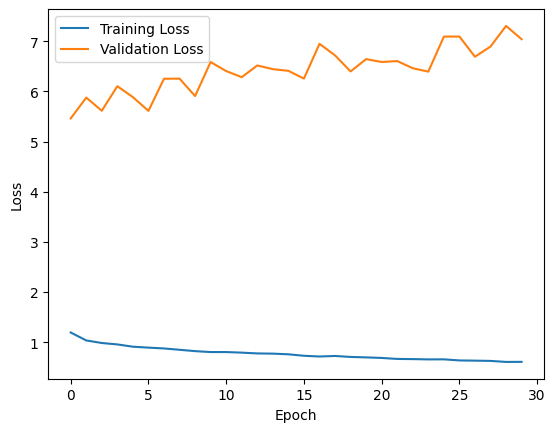

In [28]:
plt.plot(history_CNN2.history['loss'], label='Training Loss')
plt.plot(history_CNN2.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# CNN Learning Rate = 0.0001 Nadam

In [30]:
optimizer = tf.keras.optimizers.Nadam(
    learning_rate=0.0001,
    beta_1=0.9,  # 一阶矩估计衰减率
    beta_2=0.999  # 二阶矩估计衰减率
)
model_CNN.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [31]:
history_CNN3 = model_CNN.fit(
    train_dataset,
    epochs=30,
    batch_size=128,
    validation_data=val_dataset
)

Epoch 1/30
152/152 [==============================] - 14s 84ms/step - loss: 0.5881 - accuracy: 0.8278 - val_loss: 6.7580 - val_accuracy: 0.3222
Epoch 2/30
152/152 [==============================] - 13s 83ms/step - loss: 0.5935 - accuracy: 0.8237 - val_loss: 6.7719 - val_accuracy: 0.3268
Epoch 3/30
152/152 [==============================] - 13s 83ms/step - loss: 0.5908 - accuracy: 0.8262 - val_loss: 7.4158 - val_accuracy: 0.2792
Epoch 4/30
152/152 [==============================] - 13s 84ms/step - loss: 0.5719 - accuracy: 0.8309 - val_loss: 7.0426 - val_accuracy: 0.3215
Epoch 5/30
152/152 [==============================] - 13s 83ms/step - loss: 0.5827 - accuracy: 0.8305 - val_loss: 6.6764 - val_accuracy: 0.3300
Epoch 6/30
152/152 [==============================] - 12s 77ms/step - loss: 0.5952 - accuracy: 0.8230 - val_loss: 6.6991 - val_accuracy: 0.3211
Epoch 7/30
152/152 [==============================] - 12s 77ms/step - loss: 0.5522 - accuracy: 0.8413 - val_loss: 6.8053 - val_accuracy:

In [32]:
test_loss, test_acc = model_CNN.evaluate(test_dataset)
print(f"Test Accuracy: {test_acc:.4f}")

135/135 [==============================] - 26s 179ms/step - loss: 8.1593 - accuracy: 0.3166
Test Accuracy: 0.3166


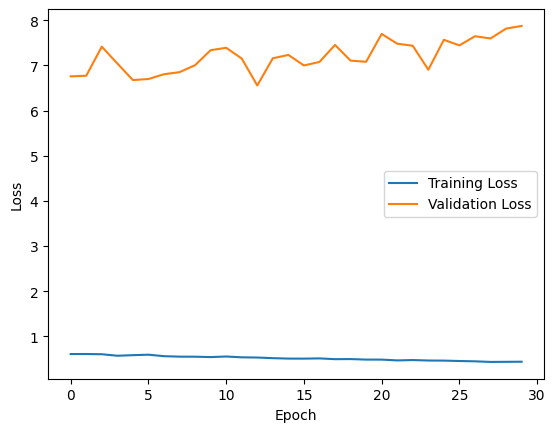

In [33]:
plt.plot(history_CNN3.history['loss'], label='Training Loss')
plt.plot(history_CNN3.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# CNN4 Learning Rate = 0.0001 SGD

In [35]:
lr_schedule = ExponentialDecay(initial_learning_rate=0.0001,
                               decay_steps=1000,
                               decay_rate=0.96,
                               staircase=True)
optimizer = tf.keras.optimizers.SGD(learning_rate=lr_schedule, momentum=0.9)
model_CNN.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

In [36]:
history_CNN4 = model_CNN.fit(
    train_dataset,
    epochs=30,
    batch_size=128,
    validation_data=val_dataset
)

Epoch 1/30
152/152 [==============================] - 12s 77ms/step - loss: 0.8333 - accuracy: 0.7933 - val_loss: 7.9229 - val_accuracy: 0.2948
Epoch 2/30
152/152 [==============================] - 12s 78ms/step - loss: 0.4899 - accuracy: 0.8549 - val_loss: 7.3378 - val_accuracy: 0.3488
Epoch 3/30
152/152 [==============================] - 12s 77ms/step - loss: 0.4739 - accuracy: 0.8611 - val_loss: 8.1903 - val_accuracy: 0.3023
Epoch 4/30
152/152 [==============================] - 12s 76ms/step - loss: 0.5096 - accuracy: 0.8533 - val_loss: 7.5732 - val_accuracy: 0.3481
Epoch 5/30
152/152 [==============================] - 12s 76ms/step - loss: 0.4933 - accuracy: 0.8568 - val_loss: 7.9239 - val_accuracy: 0.3130
Epoch 6/30
152/152 [==============================] - 12s 76ms/step - loss: 0.4542 - accuracy: 0.8673 - val_loss: 8.4279 - val_accuracy: 0.3030
Epoch 7/30
152/152 [==============================] - 12s 76ms/step - loss: 0.4386 - accuracy: 0.8733 - val_loss: 7.2483 - val_accuracy:

In [37]:
test_loss, test_acc = model_CNN.evaluate(test_dataset)
print(f"Test Accuracy: {test_acc:.4f}")

135/135 [==============================] - 2s 17ms/step - loss: 8.3790 - accuracy: 0.3245
Test Accuracy: 0.3245


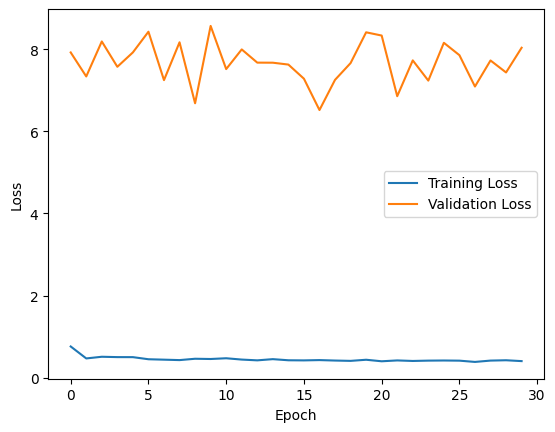

In [38]:
plt.plot(history_CNN4.history['loss'], label='Training Loss')
plt.plot(history_CNN4.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Using DeepSeek and ChatGPT for coding.